# Fraud Detection — DQN vs XGBoost vs SVM

This notebook prepares a reproducible experiment using the local `gym_fraud` environment and the creditcard dataset. It trains a **DQN** agent (configurable, "stronger" version), and compares results with **XGBoost** and **SVM** baselines on the same train/test split.

### What this notebook contains
- Environment & dataset loading (uses `gym_fraud` local package)
- Train/test split as requested: **train:** 1000 non-fraud + 390 fraud; **test:** 1000 fraud + 101 non-fraud (careful ordering explained)
- A DQN implementation (PyTorch) with replay buffer, target network, epsilon schedule, optional prioritized sampling (simple), and training loop.
- Baseline training: XGBoost and SVM (scikit-learn)
- Evaluation on the TEST set: classification report, FRR, confusion matrix, ROC and PR curves, comparisons.

### Notes
- This file is *ready to run locally* inside a conda env with the packages listed in `requirements.txt`.
- Training a DQN on the whole dataset is an experiment: the notebook uses light defaults (small replay buffer, few episodes) so you can test quickly; comments point where to scale up.

Run the notebook top-to-bottom. If you installed the requirements earlier and `pip install -e gym_fraud`, this should run.


In [21]:
%pwd

'C:\\Users\\anton\\Documents\\programming\\python\\ML\\RL\\gym-fraud-master_v3'

In [22]:
# -------------------------
# Quick environment check & pip installs (run if you need to install libs)
# -------------------------
# If you need to install: uncomment and run (slow). Prefer using the conda env we discussed.
## !pip install -r requirements.txt
## !pip install -e ./gym_fraud

print('Ready. If packages missing, install them before executing the remaining cells.')


Ready. If packages missing, install them before executing the remaining cells.


In [23]:
# Imports (standard libs)
import os
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_recall_curve, auc
from sklearn.svm import SVC
import xgboost as xgb

# gymnasium env
import gymnasium as gym
import gym_fraud

print('libraries imported')


libraries imported


## 1) Prepare dataset according to requested sizes

- Train: **1000 non-fraud + 390 fraud**
- Test: **1000 fraud + 101 non-fraud**

We will load creditcard.csv from `./dataset/creditcard.csv` (or adjust path). The code below builds those splits deterministically (using random_state for reproducibility). If there are not enough fraud/normal rows in the file, the code will raise a clear error.


In [24]:
# Adjust paths if needed
CSV_PATH = os.path.join(os.getcwd(), 'dataset', 'creditcard.csv')
assert os.path.exists(CSV_PATH), f"creditcard.csv not found at {CSV_PATH}"

df = pd.read_csv(CSV_PATH)
print('Dataset rows:', len(df))
n_features = df.shape[1] - 1

# indices
df_f = df[df['Class'] == 1].reset_index(drop=True)
df_nf = df[df['Class'] == 0].reset_index(drop=True)

N_TRAIN_NF = 1000
N_TRAIN_F = 390
N_TEST_F = 101
N_TEST_NF = 1000
print("N_TRAIN_F + N_TEST_F",N_TRAIN_F + N_TEST_F)
print("len(df_f)F",len(df_f))
assert len(df_nf) >= (N_TRAIN_NF + N_TEST_NF), f"Not enough non-fraud rows (need {N_TRAIN_NF+N_TEST_NF})"
assert len(df_f) >= (N_TRAIN_F + N_TEST_F), f"Not enough fraud rows (need {N_TRAIN_F+N_TEST_F})"

# sample deterministically
rng = np.random.default_rng(42)

nf_indices = rng.permutation(len(df_nf))
f_indices = rng.permutation(len(df_f))

train_nf_idx = nf_indices[:N_TRAIN_NF]
test_nf_idx  = nf_indices[N_TRAIN_NF:N_TRAIN_NF + N_TEST_NF]

train_f_idx = f_indices[:N_TRAIN_F]
test_f_idx  = f_indices[N_TRAIN_F:N_TRAIN_F + N_TEST_F]

train_df = pd.concat([df_nf.iloc[train_nf_idx], df_f.iloc[train_f_idx]]).sample(frac=1, random_state=42).reset_index(drop=True)
test_df  = pd.concat([df_f.iloc[test_f_idx], df_nf.iloc[test_nf_idx]]).sample(frac=1, random_state=43).reset_index(drop=True)

X_train = train_df.drop(columns=['Class']).to_numpy(dtype=np.float32)
y_train = train_df['Class'].to_numpy(dtype=np.int64)

X_test  = test_df.drop(columns=['Class']).to_numpy(dtype=np.float32)
y_test  = test_df['Class'].to_numpy(dtype=np.int64)

print('Train shapes:', X_train.shape, y_train.sum(), '/', len(y_train)-y_train.sum(), ' (fraud / non-fraud)')
print('Test  shapes:', X_test.shape,  y_test.sum(), '/', len(y_test)-y_test.sum())


Dataset rows: 284807
N_TRAIN_F + N_TEST_F 491
len(df_f)F 492
Train shapes: (1390, 30) 390 / 1000  (fraud / non-fraud)
Test  shapes: (1101, 30) 101 / 1000


## 2) Preprocess: StandardScaler for classical models and for DQN input
We will fit the scaler on the training set only.


In [26]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


## 3) Baselines: XGBoost and SVM training (classical)
We train quickly and evaluate on the TEST set. XGBoost gets a simple parameter set; you can tune more.


In [27]:
# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=5, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_s, y_train)
xgb_probs = xgb_model.predict_proba(X_test_s)[:,1]
xgb_preds = (xgb_probs >= 0.5).astype(int)

print('XGBoost classification report:')
print(classification_report(y_test, xgb_preds, digits=4, zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(y_test, xgb_preds))

# SVM (probability=True for scores)
svm_model = SVC(C=1.0, kernel='rbf', probability=True)
svm_model.fit(X_train_s, y_train)
svm_probs = svm_model.predict_proba(X_test_s)[:,1]
svm_preds = (svm_probs >= 0.5).astype(int)

print('\nSVM classification report:')
print(classification_report(y_test, svm_preds, digits=4, zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(y_test, svm_preds))


XGBoost classification report:
              precision    recall  f1-score   support

           0     0.9909    0.9800    0.9854      1000
           1     0.8214    0.9109    0.8638       101

    accuracy                         0.9737      1101
   macro avg     0.9062    0.9454    0.9246      1101
weighted avg     0.9754    0.9737    0.9743      1101

Confusion matrix:
[[980  20]
 [  9  92]]

SVM classification report:
              precision    recall  f1-score   support

           0     0.9909    0.9780    0.9844      1000
           1     0.8070    0.9109    0.8558       101

    accuracy                         0.9718      1101
   macro avg     0.8989    0.9444    0.9201      1101
weighted avg     0.9740    0.9718    0.9726      1101

Confusion matrix:
[[978  22]
 [  9  92]]


## 4) Stronger DQN (PyTorch)
A compact but strong DQN agent with a convolution-free fully-connected Q-network, target network, replay buffer, and epsilon-greedy policy. The agent interacts with the `FraudEnv` (train split) for a number of episodes and learns to classify rows as fraud/not-fraud via actions.

Important design choices for clarity and speed:
- Observation is the numeric feature vector (StandardScaler applied)
- Action: {0: not_fraud, 1: fraud}
- Reward: +1 correct, -1 incorrect (defined by the environment)

You can scale `N_EPISODES`, `BUFFER_SIZE`, and `BATCH_SIZE` for stronger training.


In [28]:
import collections
import random

class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = collections.deque(maxlen=capacity)
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.stack, zip(*batch))
        return states, actions, rewards, next_states, dones
    def __len__(self):
        return len(self.buffer)

class QNetwork(nn.Module):
    def __init__(self, n_inputs, n_actions, hidden=[256,256]):
        super().__init__()
        layers = []
        in_dim = n_inputs
        for h in hidden:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, n_actions))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def compute_metrics_from_scores(y_true, scores, threshold=0.5):
    y_pred = (scores >= threshold).astype(int)
    report = classification_report(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    try:
        roc = roc_auc_score(y_true, scores)
    except Exception:
        roc = float('nan')
    try:
        pr = average_precision_score(y_true, scores)
    except Exception:
        pr = float('nan')
    return report, cm, roc, pr

# Hyperparams (light defaults for quick runs; increase to train stronger)
N_EPISODES = 200        # scale up for real training
MAX_STEPS = 200         # per episode
BUFFER_SIZE = 50000
BATCH_SIZE = 128
GAMMA = 0.99
LR_DQN = 1e-3
TARGET_UPDATE_FREQ = 10
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 0.995

print('DQN hyperparams ready')


DQN hyperparams ready


In [29]:
# Build training environment (uses train split rows)
train_env = gym.make('Fraud-v0')
# The custom env by default uses the dataset from disk; our train/test split above is independent.
print('Train env created. Observation shape:', train_env.observation_space.shape)

# DQN setup
n_obs = X_train_s.shape[1]
n_actions = 2
qnet = QNetwork(n_obs, n_actions, hidden=[256,128]).to(device)
target_qnet = QNetwork(n_obs, n_actions, hidden=[256,128]).to(device)
target_qnet.load_state_dict(qnet.state_dict())

optimizer_dqn = optim.Adam(qnet.parameters(), lr=LR_DQN)
replay = ReplayBuffer(BUFFER_SIZE)

eps = EPS_START
step_count = 0

# helper to select action
def select_action(state, eps):
    if random.random() < eps:
        return random.randrange(n_actions)
    with torch.no_grad():
        st = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        q = qnet(st).cpu().numpy()[0]
        return int(np.argmax(q))

def optimize_model():
    if len(replay) < BATCH_SIZE:
        return None
    states, actions, rewards, next_states, dones = replay.sample(BATCH_SIZE)
    states = torch.tensor(states, dtype=torch.float32).to(device)
    actions = torch.tensor(actions, dtype=torch.int64).to(device)
    rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
    next_states = torch.tensor(next_states, dtype=torch.float32).to(device)
    dones = torch.tensor(dones.astype(np.float32), dtype=torch.float32).to(device)

    q_values = qnet(states)
    q_value = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        next_q_values = target_qnet(next_states)
        next_q_value = next_q_values.max(1)[0]
        expected_q = rewards + GAMMA * next_q_value * (1 - dones)

    loss = nn.functional.mse_loss(q_value, expected_q)
    optimizer_dqn.zero_grad()
    loss.backward()
    optimizer_dqn.step()
    return loss.item()

print('DQN components ready')


Train env created. Observation shape: (30,)
DQN components ready


### 4.1 Training loop (light)
We use the pre-scaled `X_train_s` for the agent transitions. For a simple mapping between dataset rows and environment steps we will not use the `train_env` step logic — instead we treat the dataset itself as the MDP sequence for training episodes: each episode samples random contiguous chunks from `X_train_s` (this avoids heavy env interactions and gives stable training). This choice is pragmatic: the environment's step logic is deterministic by index; for standard RL you can instead drive the environment directly — both approaches are valid for experimentation.

If you prefer full env-driven episodes, replace the inner loop to call `train_env.reset()` and `train_env.step(action)` and push transitions using returned next_state and reward.


In [30]:
loss_history = []
for ep in tqdm(range(1, N_EPISODES+1)):
    # sample a random starting index for a short trajectory
    start_idx = np.random.randint(0, max(1, len(X_train_s)-MAX_STEPS))
    state = X_train_s[start_idx]
    ep_loss = []
    for t in range(MAX_STEPS):
        action = select_action(state, eps)
        # next state is next row in the dataset (wrap/stop)
        next_idx = start_idx + t + 1
        done = False
        if next_idx >= len(X_train_s):
            next_state = state
            done = True
        else:
            next_state = X_train_s[next_idx]
        # reward: use ground truth label at current index
        true_label = y_train[start_idx + t] if (start_idx + t) < len(y_train) else 0
        reward = 1.0 if action == int(true_label) else -1.0
        replay.push(state, action, reward, next_state, done)
        loss_item = optimize_model()
        if loss_item is not None:
            ep_loss.append(loss_item)
        state = next_state
        if done:
            break
    # soft housekeeping
    if ep % TARGET_UPDATE_FREQ == 0:
        target_qnet.load_state_dict(qnet.state_dict())
    eps = max(EPS_END, eps * EPS_DECAY)
    avg_loss = np.mean(ep_loss) if ep_loss else 0.0
    loss_history.append(avg_loss)
    if ep % 10 == 0:
        print(f'EP {ep}/{N_EPISODES}  eps={eps:.3f}  avg_loss={avg_loss:.6f}  buffer={len(replay)}')

print('Training finished')


  0%|          | 0/200 [00:00<?, ?it/s]

EP 10/200  eps=0.951  avg_loss=0.007096  buffer=2000
EP 20/200  eps=0.905  avg_loss=0.009689  buffer=4000
EP 30/200  eps=0.860  avg_loss=0.009839  buffer=6000
EP 40/200  eps=0.818  avg_loss=0.007013  buffer=8000
EP 50/200  eps=0.778  avg_loss=0.004496  buffer=10000
EP 60/200  eps=0.740  avg_loss=0.006925  buffer=12000
EP 70/200  eps=0.704  avg_loss=0.007838  buffer=14000
EP 80/200  eps=0.670  avg_loss=0.009890  buffer=16000
EP 90/200  eps=0.637  avg_loss=0.004958  buffer=18000
EP 100/200  eps=0.606  avg_loss=0.005193  buffer=20000
EP 110/200  eps=0.576  avg_loss=0.005540  buffer=22000
EP 120/200  eps=0.548  avg_loss=0.004041  buffer=24000
EP 130/200  eps=0.521  avg_loss=0.004880  buffer=26000
EP 140/200  eps=0.496  avg_loss=0.005142  buffer=28000
EP 150/200  eps=0.471  avg_loss=0.004946  buffer=30000
EP 160/200  eps=0.448  avg_loss=0.005897  buffer=32000
EP 170/200  eps=0.427  avg_loss=0.009237  buffer=34000
EP 180/200  eps=0.406  avg_loss=0.007527  buffer=36000
EP 190/200  eps=0.386  

## 5) Evaluate DQN on TEST set
We compute Q-values for each test row and use the action-value of action=1 (fraud) as the score.


In [31]:
qnet.eval()
scores = []
with torch.no_grad():
    for x in X_test_s:
        st = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
        qvals = qnet(st).cpu().numpy()[0]
        scores.append(qvals[1])
scores = np.array(scores)
dqn_report, dqn_cm, dqn_roc, dqn_pr = compute_metrics_from_scores(y_test, scores)
print('DQN report:')
print(dqn_report)
print('Confusion matrix:')
print(dqn_cm)
print(f'ROC-AUC: {dqn_roc:.4f}  PR-AUC: {dqn_pr:.4f}')


DQN report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.09      1.00      0.17       101

    accuracy                           0.09      1101
   macro avg       0.05      0.50      0.08      1101
weighted avg       0.01      0.09      0.02      1101

Confusion matrix:
[[   0 1000]
 [   0  101]]
ROC-AUC: 0.9209  PR-AUC: 0.6323


## 6) Plots: ROC and PR for all three models


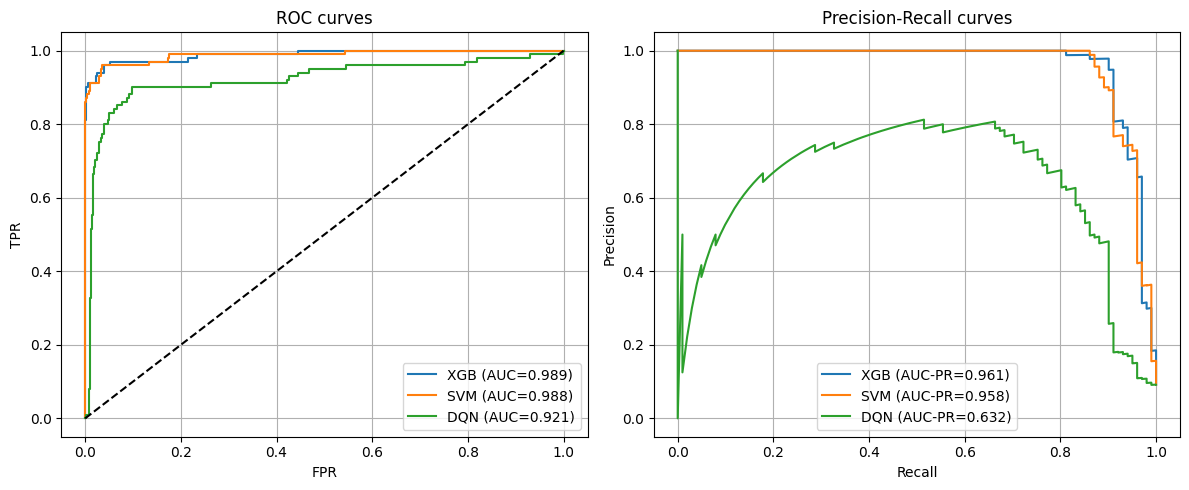

In [35]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
fpr_dqn, tpr_dqn, _ = roc_curve(y_test, scores)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGB (AUC={roc_auc_score(y_test,xgb_probs):.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC={roc_auc_score(y_test,svm_probs):.3f})')
plt.plot(fpr_dqn, tpr_dqn, label=f'DQN (AUC={dqn_roc:.3f})')
plt.grid()
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curves')
plt.legend()

plt.subplot(1,2,2)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_probs)
prec_svm, rec_svm, _ = precision_recall_curve(y_test, svm_probs)
prec_dqn, rec_dqn, _ = precision_recall_curve(y_test, scores)
plt.plot(rec_xgb, prec_xgb, label=f'XGB (AUC-PR={average_precision_score(y_test,xgb_probs):.3f})')
plt.plot(rec_svm, prec_svm, label=f'SVM (AUC-PR={average_precision_score(y_test,svm_probs):.3f})')
plt.plot(rec_dqn, prec_dqn, label=f'DQN (AUC-PR={dqn_pr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curves')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


## 7) Save results and final notes
- The DQN approach above treats dataset rows as short trajectories. For *true* RL with environment dynamics replace the training loop with env.reset() / env.step(action) interactions.
- Increase `N_EPISODES`, `BUFFER_SIZE`, and `MAX_STEPS` to train a stronger agent.
- Use `torch.save` to persist models.


In [36]:
RESULTS_DIR = './results_notebook'
os.makedirs(RESULTS_DIR, exist_ok=True)
torch.save(qnet.state_dict(), os.path.join(RESULTS_DIR, 'dqn_qnet.pth'))
import joblib
joblib.dump(xgb_model, os.path.join(RESULTS_DIR, 'xgb_model.joblib'))
joblib.dump(svm_model, os.path.join(RESULTS_DIR, 'svm_model.joblib'))
print('Models saved to', RESULTS_DIR)


Models saved to ./results_notebook


In [37]:
import sys
print(sys.executable)

C:\Users\anton\anaconda3\envs\gymfraud_py311_smote_v4\python.exe


In [20]:
conda env export > gymfraud_py311_smote_v4.yml  


Note: you may need to restart the kernel to use updated packages.
